In [16]:
# %pip install -q transformers torch scikit-learn seaborn matplotlib

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
texts = [
    "I absolutely loved this movie, it was wonderful.",
    "The product quality is excellent and I am very happy.",
    "Amazing experience, would definitely recommend it.",
    "The food was delicious and the service was great.",
    "This app is very useful and easy to use.",
    "I am satisfied with the purchase.",
    "The support team solved my issue quickly.",
    "Great value for money, totally worth it.",
    "I enjoyed every moment of the event.",
    "This is one of the best books I have read.",
    "The performance was outstanding and impressive.",
    "I love the design and user interface.",
    "Best decision ever, highly satisfied.",
    "The quality exceeded my expectations.",
    "Fantastic customer service experience.",
    "This product changed my life for the better.",
    "I am thrilled with the results.",
    "Excellent value and top-notch quality.",
    "The team was professional and helpful.",
    "This is absolutely perfect.",
    "I cannot be happier with this choice.",
    "The delivery was fast and the product is great.",
    "This exceeded all my expectations.",
    "Wonderful experience from start to finish.",
    "I would recommend this to everyone.",
    "I hated the experience, it was terrible.",
    "Very disappointing product, it broke in one day.",
    "The service was slow and the staff was rude.",
    "I am unhappy with the app performance.",
    "Waste of money, not recommended at all.",
    "The movie was boring and too long.",
    "I regret buying this item.",
    "Bad quality and poor packaging.",
    "The update made everything worse.",
    "It was a frustrating and annoying process.",
    "This is a complete disaster.",
    "Terrible quality, total waste.",
    "The support team was unhelpful and rude.",
    "I am extremely disappointed.",
    "This product is useless.",
    "The worst purchase I have ever made.",
    "I hate everything about this.",
    "Unacceptable quality and service.",
    "I want a refund immediately.",
    "This is completely broken.",
    "Never buying from them again.",
    "Awful experience, do not recommend.",
    "The product fell apart instantly.",
    "Absolutely horrible, save your money.",
    "The worst product I have tried."
]

labels = [1] * 25 + [0] * 25

print(f"Total samples: {len(texts)}")
print(f"Positive samples: {sum(labels)}")
print(f"Negative samples: {len(labels) - sum(labels)}")

Total samples: 50
Positive samples: 25
Negative samples: 25


In [18]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

print(f"Model loaded: {model_name}")
print(f"Running on: {device}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2516.95it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: bert-base-uncased
Running on: cuda


In [19]:
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = torch.sum(masked_embeddings, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

def encode_texts(input_texts, batch_size=8):
    all_embeddings = []

    for i in range(0, len(input_texts), batch_size):
        batch = input_texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert_model(**encoded)

        pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
        all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)

X = encode_texts(texts)
y = np.array(labels)

print(f"Embedding matrix shape: {X.shape}")

Embedding matrix shape: (50, 768)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

print("Classifier training complete.")

Classifier training complete.


Accuracy: 1.000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         8
    Positive       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



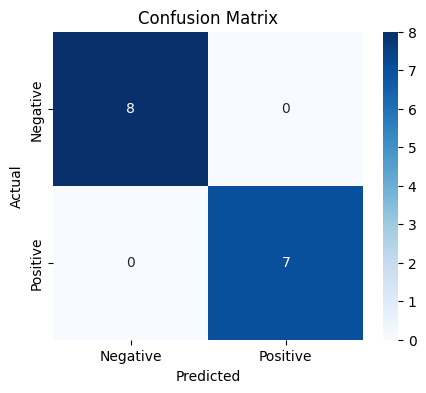

In [21]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
new_sentences = [
    "The lecture was very interesting and easy to follow.",
    "This phone has terrible battery life.",
    "I am quite happy with the final results.",
    "The assignment instructions were confusing and stressful.",
    "The movie was excellent",
    "Our teacher for this course is very helpful and knowledgeable.",
    "My neighbors are very noisy and disruptive."
]

new_X = encode_texts(new_sentences)
new_preds = clf.predict(new_X)

for sent, pred in zip(new_sentences, new_preds):
    label = "Positive" if pred == 1 else "Negative"
    print(f"{label:8s} | {sent}")

Positive | The lecture was very interesting and easy to follow.
Negative | This phone has terrible battery life.
Positive | I am quite happy with the final results.
Negative | The assignment instructions were confusing and stressful.
Positive | The movie was excellent
Positive | Our teacher for this course is very helpful and knowledgeable.
Negative | My neighbors are very noisy and disruptive.
